# Stock-Market

#### Define the Scope and Objective:
#### Data Collection:
#### Data Preparation:
#### Exploratory Data Analysis (EDA):
#### Feature Engineering:
#### Model Selection:
#### Model Training and Evaluation:
#### Model Tuning and Optimization:
#### Deployment:

In [71]:
# Import required libraries

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

#### Data Collection (Load Dataset)

In [72]:
# Load the dataset
df = pd.read_csv('Downloads/stocks.csv')
df.head(10)

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
5,AAPL,2023-02-14,152.119995,153.770004,150.860001,153.199997,153.199997,61707600
6,AAPL,2023-02-15,153.110001,155.500000,152.880005,155.330002,155.330002,65573800
7,AAPL,2023-02-16,153.509995,156.330002,153.350006,153.710007,153.710007,68167900
8,AAPL,2023-02-17,152.350006,153.000000,150.850006,152.550003,152.550003,59144100
9,AAPL,2023-02-21,150.199997,151.300003,148.410004,148.479996,148.479996,58867200


## Data Preparation

In [73]:
df.isnull().sum()          # check missing value

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [74]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
# Sort data by date
df = df.sort_values(by='Date')
df.dtypes

Ticker               object
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [75]:
# Remove duplicates
df.drop_duplicates(inplace=True)

## Exploratory Data Analysis (EDA)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Ticker     248 non-null    object        
 1   Date       248 non-null    datetime64[ns]
 2   Open       248 non-null    float64       
 3   High       248 non-null    float64       
 4   Low        248 non-null    float64       
 5   Close      248 non-null    float64       
 6   Adj Close  248 non-null    float64       
 7   Volume     248 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 17.4+ KB


In [77]:
df.shape

(248, 8)

##### Mean, minimum, maximum stock prices
##### Price variation and volatility
##### Trading volume range


In [78]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,248,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,2023-03-22 22:27:05.806451712,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
min,2023-02-07 00:00:00,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,2023-03-01 00:00:00,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,2023-03-22 12:00:00,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,2023-04-14 00:00:00,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,2023-05-05 00:00:00,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08
std,NaN,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07


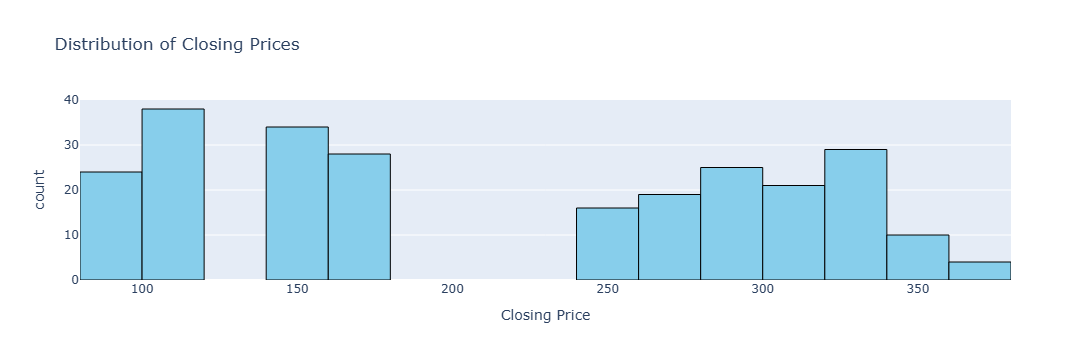

In [79]:
import plotly.express as px
# Histogram 
fig = px.histogram(
    df,
    x="Close",
    nbins=20,
    title="Distribution of Closing Prices",
    labels={"Close": "Closing Price"},
    color_discrete_sequence=["skyblue"]  # bar color
)

# Add border line to bars
fig.update_traces(marker=dict(line=dict(color="black", width=1)  # border line
    )
)

# Show interactive plot
fig.show()

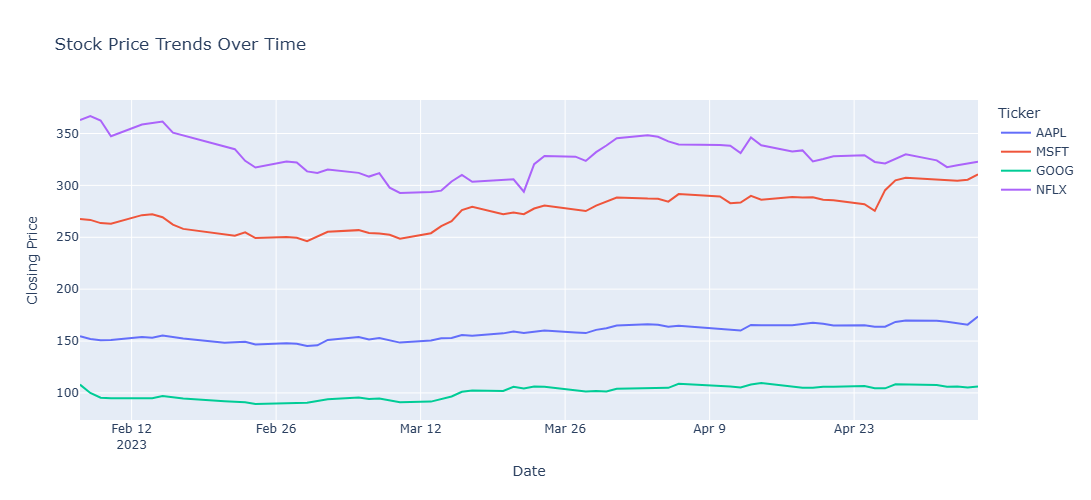

In [80]:
fig = px.line(
    df,
    x="Date",
    y="Close",
    color="Ticker",
    title="Stock Price Trends Over Time",
    labels={"Close": "Closing Price", "Date": "Date"}
)

fig.update_traces(line=dict(width=2))

# Medium size
fig.update_layout(width=1000, height=500)

fig.show()

In [81]:
df["MA20"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())
df["MA50"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(50).mean())

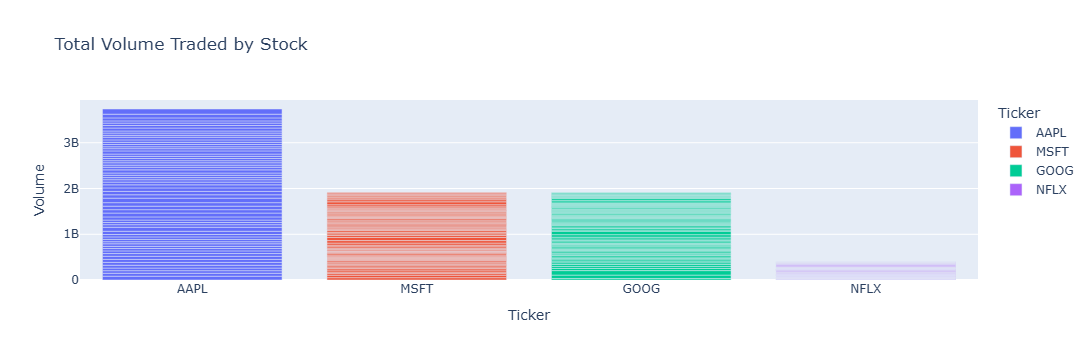

In [82]:
#  Bar Chart: Total Volume by Ticker ---
fig_bar = px.bar(
    df,
    x="Ticker",
    y="Volume",
    title="Total Volume Traded by Stock",
    color="Ticker"
)
fig_bar.show()

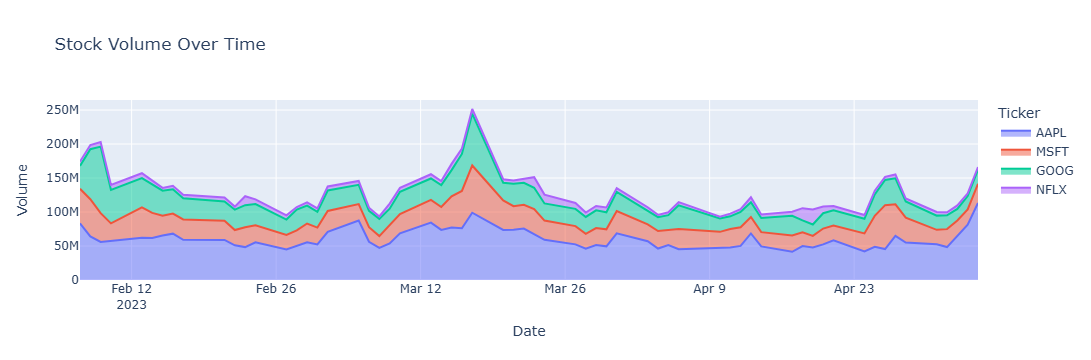

In [83]:
fig_volume = px.area(
    df,
    x="Date",
    y="Volume",
    color="Ticker",
    title="Stock Volume Over Time"
)
fig_volume.show()

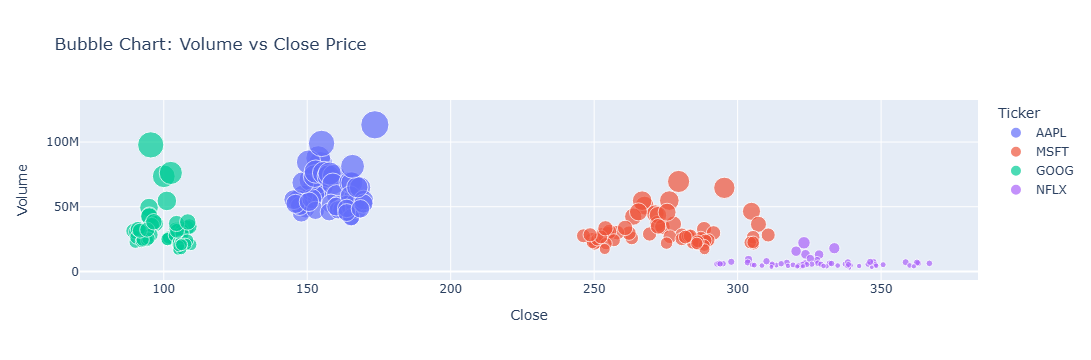

In [84]:
#  Bubble Chart: Volume vs Close Price ---
fig_bubble = px.scatter(
    df,
    x="Close",
    y="Volume",
    size="Volume",
    color="Ticker",
    title="Bubble Chart: Volume vs Close Price"
)
fig_bubble.show()

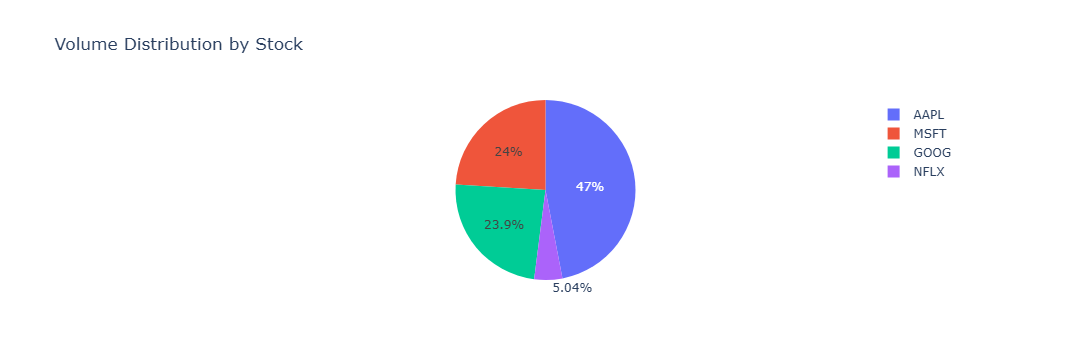

In [85]:

# Pie Chart: Distribution of Volume by Stock ---
fig_pie = px.pie(
    df,
    names="Ticker",
    values="Volume",
    title="Volume Distribution by Stock"
)
fig_pie.show()

In [86]:
# Calculate daily return percentage
df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()

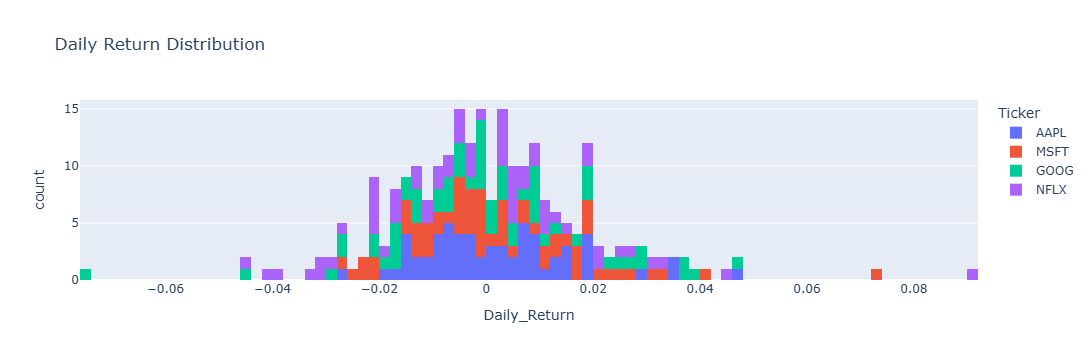

In [87]:
# Return Distribution
fig_return = px.histogram(
    df,
    x="Daily_Return",
    color="Ticker",
    nbins=100,
    title="Daily Return Distribution"
)
fig_return.show()

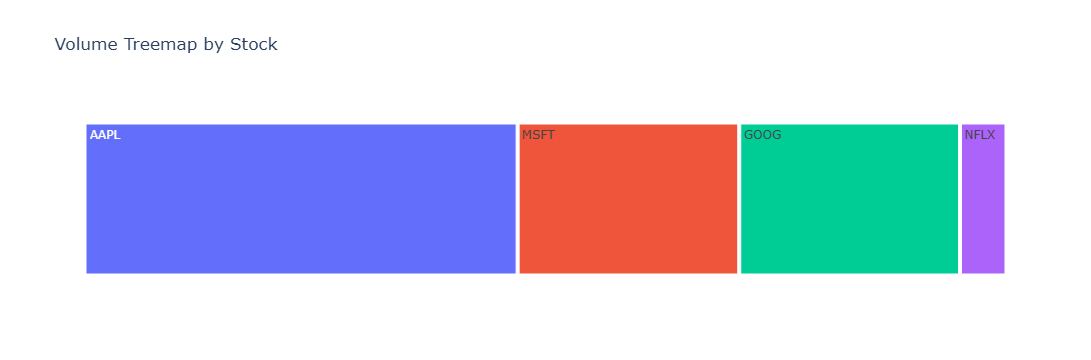

In [88]:
# Tree Map: Volume by Ticker only (no date level)
fig_tree = px.treemap(
    df,
    path=["Ticker"],  # Only show Ticker at top level
    values="Volume",
    title="Volume Treemap by Stock"
)
fig_tree.show()

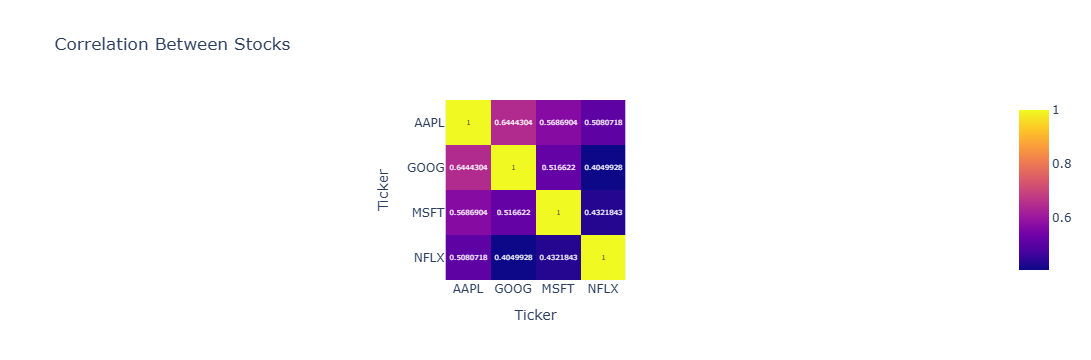

In [89]:
# Correlation Analysis
returns = df.pivot(index="Date", columns="Ticker", values="Daily_Return")
corr_matrix = returns.corr()

fig_corr = px.imshow(
    corr_matrix,
    text_auto=True,
    title="Correlation Between Stocks"
)
fig_corr.show()

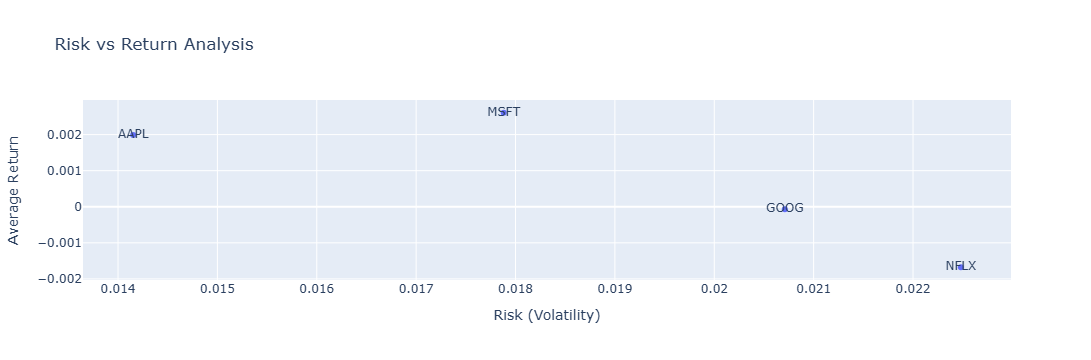

In [90]:
# Risk vs Return Analysis
risk_return = pd.DataFrame({
    "Average Return": returns.mean(),
    "Risk (Volatility)": returns.std()
})

fig_risk = px.scatter(
    risk_return,
    x="Risk (Volatility)",
    y="Average Return",
    text=risk_return.index,
    title="Risk vs Return Analysis"
)
fig_risk.show()

## Feature Engineering

In [91]:
# Moving averages
df["MA20"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())
df["MA50"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(50).mean())

# Rolling volatility
df["Volatility"] = df.groupby("Ticker")["Daily_Return"].transform(lambda x: x.rolling(20).std())

# Drop NA values created by rolling
model_df = df.dropna()

### Model Selection & Training

In [92]:
# Define features and target
X = model_df[["Open", "High", "Low", "Volume", "MA20", "MA50", "Volatility"]]
y = model_df["Close"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [93]:
# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 3.6305977766696547
R2 Score: 0.9995862594458185


## Model Tuning

In [94]:
# Hyperparameter tuning using GridSearch

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Deployment & Dashboard

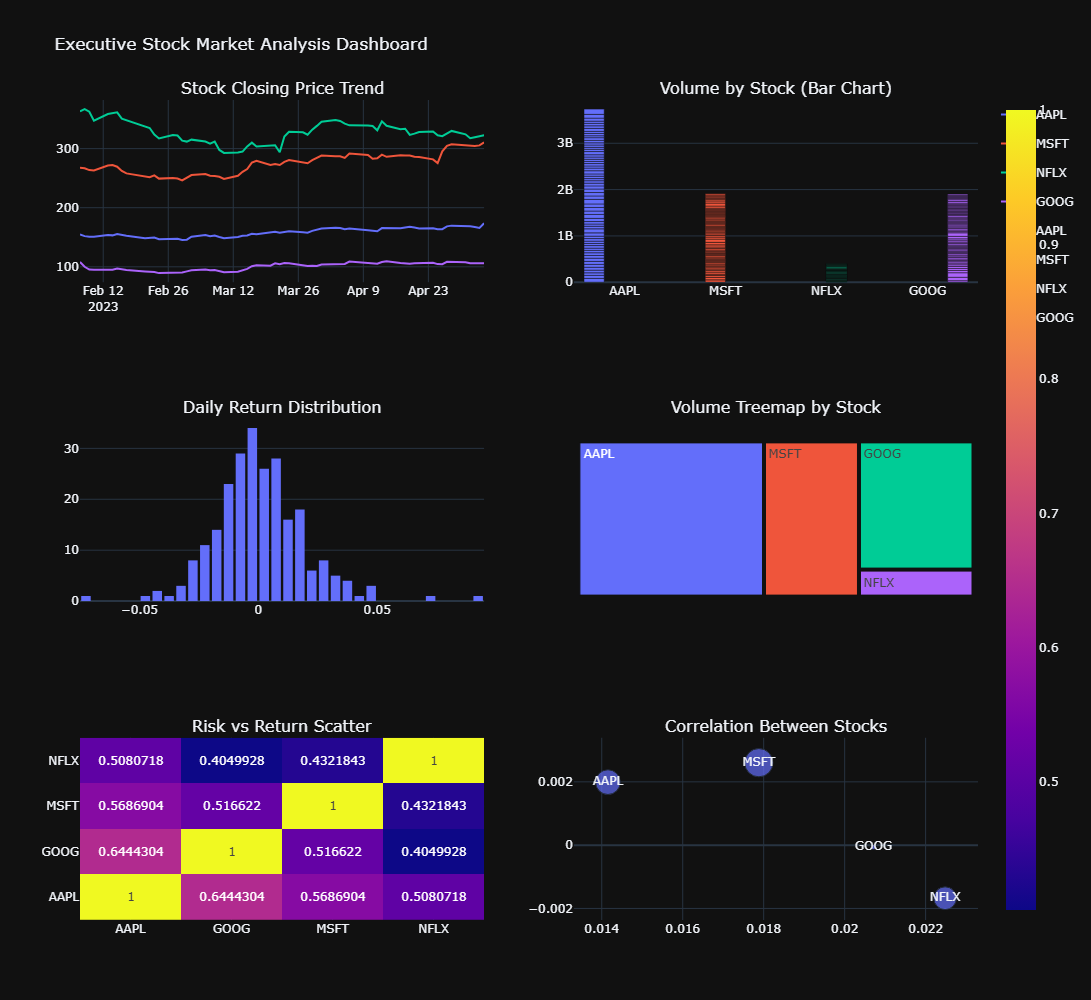

In [95]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load the data
df = pd.read_csv("Downloads/stocks.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Feature Engineering
df["Year"] = df["Date"].dt.year
df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()
df["Cumulative_Return"] = (1 + df["Daily_Return"]).groupby(df["Ticker"]).cumprod()

# Create a subplot with 3 rows and 2 columns
dashboard = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Stock Closing Price Trend",
        "Volume by Stock (Bar Chart)",
        "Daily Return Distribution",
        "Volume Treemap by Stock",
        "Risk vs Return Scatter",
        "Correlation Between Stocks"
    ),
    specs=[[{"type": "scatter"}, {"type": "bar"}],
           [{"type": "histogram"}, {"type": "treemap"}],
           [{"type": "scatter"}, {"type": "scatter"}]]
)

# 1. Stock Closing Price Trend (Line Chart)
for ticker in df["Ticker"].unique():
    stock = df[df["Ticker"] == ticker]
    dashboard.add_trace(
        go.Scatter(x=stock["Date"], y=stock["Close"], mode='lines', name=ticker),
        row=1, col=1
    )

# 2. Volume by Stock (Bar Chart)
fig_bar = px.bar(df, x="Ticker", y="Volume", color="Ticker", title="Volume by Stock")
for trace in fig_bar.data:
    dashboard.add_trace(trace, row=1, col=2)

# 3. Daily Return Distribution (Histogram)
fig_hist = px.histogram(df, x="Daily_Return", nbins=50, title="Daily Return Distribution")
for trace in fig_hist.data:
    dashboard.add_trace(trace, row=2, col=1)

# 4. Volume Treemap by Stock (Treemap)
fig_tree = px.treemap(df, path=["Ticker"], values="Volume", title="Volume Treemap by Stock")
for trace in fig_tree.data:
    dashboard.add_trace(trace, row=2, col=2)

# 5. Risk vs Return Scatter (Scatter Plot)
risk_return = df.groupby("Ticker").agg(
    Return=('Daily_Return', 'mean'),
    Risk=('Daily_Return', 'std')
).reset_index()

fig_scatter = px.scatter(
    risk_return, x="Risk", y="Return", text="Ticker", size=risk_return["Return"].abs(), title="Risk vs Return"
)
for trace in fig_scatter.data:
    dashboard.add_trace(trace, row=3, col=2)

# 6. Correlation Between Stocks (Heatmap)
returns = df.pivot(index="Date", columns="Ticker", values="Daily_Return")
corr = returns.corr()

fig_corr = px.imshow(corr, text_auto=True, title="Correlation Between Stocks")
for trace in fig_corr.data:
    dashboard.add_trace(trace, row=3, col=1)

# Update layout and show dashboard
dashboard.update_layout(
    height=1000,
    title_text="Executive Stock Market Analysis Dashboard",
    template="plotly_dark"
)

dashboard.show()